# Modeling

#### The goal of this notebook is to train and compare three machine learning models Logistic Regression, Random Forest, and XGBoost to predict credit risk using the preprocessed data from the prep_EDA notebook. Given the class imbalance in the dataset, models are evaluated using ROC-AUC and precision-recall rather than accuracy alone.

Import Libraries

In [32]:
import pandas as pd
from pathlib import Path
import joblib
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score

Importing Data

In [33]:
from pathlib import Path

BASE_DIR = Path().resolve().parent
DATA_PATH = BASE_DIR / 'data' / 'data1.csv'
MODELS_DIR = BASE_DIR / 'models'

df = pd.read_csv(DATA_PATH)

Dropping the Target column from the Training set

In [34]:
y = df['default_status']
x = df.drop(columns=['default_status'])

Splitting the Data into Training and Testing sets

In [35]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

Dealing with Imbalance using SMOTE

Smote was chosen to handle class imbalance because it reduced the likelihood of overfitting unlike random oversampling SMOTE is applied only to the training data to prevent data leakage and ensure a realistic, unbiased evaluation of the model

In [36]:

x_resampled, y_resampled = SMOTE(random_state=42).fit_resample(x_train, y_train)

Scaling

Scaling is only strictly necessary for Logistic Regression. XGBoost and Random Forest are tree-based and scale-invariant. Everything is being scaled for consistency as all three models share the same pipeline

In [37]:
stsc=StandardScaler()
xtrain=stsc.fit_transform(x_resampled)
xtest=stsc.transform(x_test)

In [38]:
x_resampled.columns

Index(['age', 'income', 'home_ownership', 'employment_years', 'loan_purpose',
       'loan_grade', 'loan_amount', 'interest_rate', 'loan_to_income',
       'has_previous_default', 'credit_history_years'],
      dtype='object')

Model Training

Logistic Regression

In [39]:

lg=LogisticRegression()
lg.fit(xtrain,y_resampled)
y_pred_lg=lg.predict(xtest)


print(roc_auc_score(y_test, lg.predict_proba(xtest)[:, 1]))
print(confusion_matrix(y_test, y_pred_lg))
print(classification_report(y_test, y_pred_lg))

0.8295033755372438
[[3961 1138]
 [ 415 1001]]
              precision    recall  f1-score   support

           0       0.91      0.78      0.84      5099
           1       0.47      0.71      0.56      1416

    accuracy                           0.76      6515
   macro avg       0.69      0.74      0.70      6515
weighted avg       0.81      0.76      0.78      6515



Random Forest

In [40]:
rf=RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(xtrain,y_resampled)
y_pred_rf = rf.predict(xtest)


print(roc_auc_score(y_test, rf.predict_proba(xtest)[:, 1]))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


0.9269659194280921
[[4812  287]
 [ 335 1081]]
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      5099
           1       0.79      0.76      0.78      1416

    accuracy                           0.90      6515
   macro avg       0.86      0.85      0.86      6515
weighted avg       0.90      0.90      0.90      6515



XgBoost

In [41]:
xg=XGBClassifier(
    n_estimators=200,
    max_depth=5,
    eval_metric='logloss',
    random_state=42)

xg.fit(xtrain,y_resampled)

y_pred = xg.predict(xtest)
print(roc_auc_score(y_test, xg.predict_proba(xtest)[:, 1]))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9451786824269298
[[5004   95]
 [ 337 1079]]
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      5099
           1       0.92      0.76      0.83      1416

    accuracy                           0.93      6515
   macro avg       0.93      0.87      0.90      6515
weighted avg       0.93      0.93      0.93      6515



## Model Comparison

| Model               | AUC  | Precision           | Recall           | F1           |
|---------------------|------|---------------------|------------------|--------------|
| Logistic Regression | 0.83 | 0.47                | 0.71             | 0.56         |
| Random Forest       | 0.93 | 0.79                | 0.76             | 0.78         |
| XGBoost             | 0.95 | 0.92                | 0.76             | 0.83         |

With the highest AUC (0.95) and precision on the default class (0.92),when XGBoost predicts a default, it is correct 92% of the time. This is especially helpful in the context of credit risk since it is more expensive to approve a loan that defaults than to reject a qualified borrower, so accuracy on the default class is crucial. As a result, XGBoost was chosen for implementation.

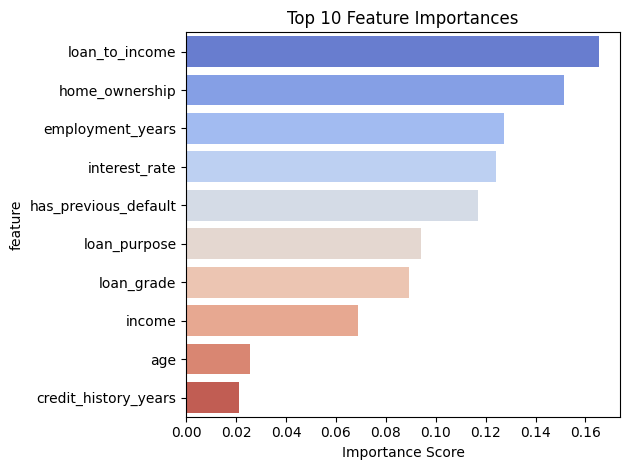

In [42]:
import matplotlib.pyplot as plt
importance_df = pd.DataFrame({
    'feature': x.columns,
    'importance': xg.feature_importances_
}).sort_values('importance', ascending=False).head(10)

sns.barplot(data=importance_df, x='importance', y='feature', palette='coolwarm',hue = 'feature',legend=False)
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

Loan-to-income ratio and home ownership are the most important predictors, 
suggesting that financial stability and housing security are strong indicators 
of repayment ability. This aligns with the EDA findings. Credit history length 
and age were less influential, consistent with their high intercorrelation noted earlier.

Exporting Model for Deployment

In [43]:
joblib.dump(xg, MODELS_DIR / 'xgboost.pkl')
joblib.dump(stsc, MODELS_DIR / 'scaler.pkl')

['D:\\PROJECTS\\Credit Risk Prediction\\models\\scaler.pkl']

In [44]:
print(y_resampled.value_counts())
print(y_test.value_counts())
print(pd.Series(xg.predict(xtest)).value_counts())

default_status
0    20368
1    20368
Name: count, dtype: int64
default_status
0    5099
1    1416
Name: count, dtype: int64
0    5341
1    1174
Name: count, dtype: int64
